# Machine Learning — Prédiction du Churn Bancaire

Plan du notebook

1. Import des données (PostgreSQL, avec repli automatique)
	* Importer les données depuis postgres
	* Choisir le grain (churn d'un client et non pas d'un compte )
	* Affichage du dataframe
	* Affichage du type des variables
	* Affichage des valeurs manquantes non tranchées lors de l'ETL (transformer en colonne identifier 	les fuite des signaux métier :  _ missing en plus de l'imputation ou exclure si artefact à voir dans 	4.Bis)
2. Analyse exploratoire orientée ML
	* Analyse de la distribution de y (comment on va gérer unbalanced data ? quel 	métrique choisir Accuracy)
	* Analyse des variables quanti pour décider de la standardisation (section 6)
	* Analyse de la relation entre variable quanti et y (a titre indicatif , on peut supprimer)
	* Analyse de la corrélation entre variables (pour éliminer certaines redondance = 	feature selection)
3. Sélection des variables (feature selection)
	Exclure
		* les variables qui sont saisies en post y car ne permettent pas de prédire le churn,
		* la Variable Y
		* Les variables sans valeur prédictive selon l'expertise métier
		* Les variables à forte cardinalité
		* Les variables quasi constante
4. Séparation X / y
4.bis Traitement des valeurs manquantes
	* Vérifier la corrélation avec churn
	* Classer en fuite ou signal métier
	* Les signaux métier : imputation et ajouter colonne missing
5. Encodage des variables catégorielles
	* Choisir les variables pour One Hot Encoder et Encodage par fréquence
	* Réaliser que le Hot One encoder avant le split
7. Découpage train/test
	* Encodage par fréquence en post split pour éviter le data leak
------------------------------------------------
6. Mise à l'échelle (scaling)
	* standardiser les variables numériques sur Xtrain seulement (vu en étape 2)
8. Gestion du déséquilibre de classes (SMOTE)
	* Smote sur X_train seulement (on ne touche pas le test)
9. Modèle de référence (régression logistique)
	* entrainement model de ref
	* Matrice de confusion model ref
	* Comparaison métriques model ref
	* Courbe ROC et AUC
10. Comparaison de plusieurs modèles
11. Tableau comparatif
12. Importance des variables
13. Conclusion

## 1. Import des données

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

RANDOM_STATE = 42  # graine fixe unique pour tout le notebook, voir section 7

In [2]:
def load_from_postgres():
    """Tente de charger les tables nécessaires directement depuis PostgreSQL.

    Retourne un dict {nom_table: DataFrame} en cas de succès, ou None en cas
    d'échec (serveur non démarré, identifiants invalides...) — la fonction
    appelante décide alors de basculer sur le pipeline ETL en mémoire.
    """
    import os
    from sqlalchemy import create_engine

    db_user = os.environ.get("DB_USER", "postgres")
    db_password = os.environ.get("DB_PASSWORD", "postgres")
    db_host = os.environ.get("DB_HOST", "localhost")
    db_port = os.environ.get("DB_PORT", "5432")
    db_name = os.environ.get("DB_NAME", "PIProject")

    connection_string = (
        f"postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"
        f"?client_encoding=utf8"
    )

    try:
        engine = create_engine(connection_string, connect_args={"client_encoding": "utf8"})
        tables = {}
        for table_name in ["fact_account_event", "dim_account", "dim_client", "dim_branch"]:
            tables[table_name] = pd.read_sql_table(table_name, con=engine)
        print("Connexion PostgreSQL réussie — données importées depuis la base.")
        return tables
    except Exception as exc:
        print(f"[INFO] Connexion PostgreSQL impossible ({type(exc).__name__}: {exc}).")
        print("       Bascule sur le pipeline ETL en mémoire (etl_pipeline.pipeline).")
        return None


def load_from_etl_pipeline():
    """Repli : reconstruit les mêmes tables via le pipeline ETL en mémoire,
    sans dépendre d'une connexion PostgreSQL. Localise etl_pipeline/ en
    remontant depuis le répertoire courant, comme run.py le fait déjà.
    """
    search_dir = Path.cwd()
    for _ in range(4):
        if (search_dir / "01_etl" / "etl_pipeline").is_dir():
            sys.path.insert(0, str(search_dir / "01_etl"))
            break
        if (search_dir / "etl_pipeline").is_dir():
            sys.path.insert(0, str(search_dir))
            break
        search_dir = search_dir.parent
    else:
        raise ImportError(
            "Impossible de localiser etl_pipeline/ — vérifiez que ce notebook "
            "est bien situé sous 01_etl/notebooks/ ou à la racine du projet."
        )

    from etl_pipeline.pipeline import run_pipeline
    resultats = run_pipeline(load_to_db=False)

    return {
        "fact_account_event": resultats["fact_account_event"],
        "dim_account": resultats["dimensions"]["dim_account"],
        "dim_client": resultats["dimensions"]["dim_client"],
        "dim_branch": resultats["dimensions"]["dim_branch"],
    }


tables = load_from_postgres()
if tables is None:
    tables = load_from_etl_pipeline()

fact_account_event = tables["fact_account_event"]
dim_account = tables["dim_account"]
dim_client = tables["dim_client"]
dim_branch = tables["dim_branch"]

print(f"\nfact_account_event : {fact_account_event.shape}")
print(f"dim_account         : {dim_account.shape}")
print(f"dim_client          : {dim_client.shape}")
print(f"dim_branch          : {dim_branch.shape}")

18:38:10 | INFO     | etl_pipeline.pipeline | ======================================================================
18:38:10 | INFO     | etl_pipeline.pipeline | DÉBUT DU PIPELINE ETL
18:38:10 | INFO     | etl_pipeline.pipeline | ======================================================================
18:38:10 | INFO     | etl_pipeline.pipeline | --- ÉTAPE 1/5 : EXTRACT ---


[INFO] Connexion PostgreSQL impossible (ValueError: Table fact_account_event not found).
       Bascule sur le pipeline ETL en mémoire (etl_pipeline.pipeline).


18:38:12 | INFO     | etl_pipeline.extract | Extraction terminée : 528,883 lignes, 34 colonnes
18:38:12 | WARNING  | etl_pipeline.extract | Dimension 'category_account' introuvable (C:\Users\HP\OneDrive\Bureau\ESB\ML\Mon_projet_git\ProjetIntegre_Churn_HAFAS\data\dim_CATEGORY_ACCOUNT.xlsx) — ignorée.
18:38:12 | WARNING  | etl_pipeline.extract | Échec de lecture de la dimension 'currency' : Excel file format cannot be determined, you must specify an engine manually.
18:38:12 | WARNING  | etl_pipeline.extract | Dimension 'closure_reason' introuvable (C:\Users\HP\OneDrive\Bureau\ESB\ML\Mon_projet_git\ProjetIntegre_Churn_HAFAS\data\dim_Closure_reason.xlsx) — ignorée.
18:38:12 | WARNING  | etl_pipeline.extract | Échec de lecture de la dimension 'dao' : Excel file format cannot be determined, you must specify an engine manually.
18:38:12 | WARNING  | etl_pipeline.extract | Échec de lecture de la dimension 'industry' : Excel file format cannot be determined, you must specify an engine manually


fact_account_event : (445803, 14)
dim_account         : (410587, 11)
dim_client          : (319129, 15)
dim_branch          : (141, 6)


### Construction du jeu de données au grain compte

`fact_account_event` est au grain **événement**, On agrège donc d'abord au grain **Client** 

In [3]:
agg_fact = fact_account_event.groupby("account_key").agg(
    acct_balance=("acct_balance", "mean"),
    salary=("salary", "mean"),
    amount_total=("amount", "sum"),
    fixedrate_mean=("fixedrate", "mean"),
    nb_produits=("product_key", "count"),
    churn=("churn", "max"),
).reset_index()

# Récupère les clés client/branche (stables par compte, vérifié : 0 compte avec
# plusieurs client_key ou branch_key distincts dans l'ETL).
keys = fact_account_event[["account_key", "client_key", "branch_key"]].drop_duplicates(
    subset="account_key"
)
df_ml = agg_fact.merge(keys, on="account_key", how="left")

print(f"Jeu de données au grain compte : {df_ml.shape[0]:,} comptes")
print(f"Taux de churn : {df_ml['churn'].mean()*100:.1f}%")

Jeu de données au grain compte : 410,587 comptes
Taux de churn : 36.1%


In [4]:
# Jointure avec les attributs de compte, client et branche
df_ml = df_ml.merge(
    dim_account[["account_key", "ACCOUNT_CATEGORY", "ACCOUNT_TYPE_DESC", "CURRENCY",
                 "acct_tenure_days", "nb_accounts_per_client"]],
    on="account_key", how="left",
)
df_ml = df_ml.merge(
    dim_client[["client_key", "age", "MARITAL_STATUS", "NATURE_CLIENT", "PARTYCLASS",
                "LOB", "SCORE_KYC", "COMPLETED_FILE"]],
    on="client_key", how="left",
)
df_ml = df_ml.merge(dim_branch[["branch_key", "BRANCH"]], on="branch_key", how="left")

print(f"df_ml final : {df_ml.shape[0]:,} lignes x {df_ml.shape[1]} colonnes")

df_ml final : 410,587 lignes x 22 colonnes


### Aperçu de la structure du jeu de données

In [5]:
df_ml.head()

,account_key,acct_balance,salary,amount_total,fixedrate_mean,nb_produits,churn,client_key,branch_key,ACCOUNT_CATEGORY,...,acct_tenure_days,nb_accounts_per_client,age,MARITAL_STATUS,NATURE_CLIENT,PARTYCLASS,LOB,SCORE_KYC,COMPLETED_FILE,BRANCH
0,ACC_000001,-10714.347,2725.739,21909200.0,4.5,2,1,CLI_280670,BRA_001,3023.0,...,2346.0,4,57,M,PPH,Retail,4,LR,YES,BR114
1,ACC_000002,0.000,3300.537,0.0,0.0,2,1,CLI_280672,BRA_001,3611.0,...,NaN,6,66,M,PPH,Retail,4,LR,YES,BR114
2,ACC_000003,-113033.101,2725.739,227186154.0,4.5,2,1,CLI_280670,BRA_001,3017.0,...,961.0,4,57,M,PPH,Retail,4,LR,YES,BR114
3,ACC_000004,0.000,2725.739,0.0,0.0,2,1,CLI_280670,BRA_001,1011.0,...,1342.0,4,57,M,PPH,Retail,4,LR,YES,BR114
4,ACC_000005,0.000,3300.537,0.0,0.0,2,1,CLI_280672,BRA_001,3611.0,...,NaN,6,66,M,PPH,Retail,4,LR,YES,BR114


In [6]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 410587 entries, 0 to 410586
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   account_key             410587 non-null  object 
 1   acct_balance            310102 non-null  float64
 2   salary                  178834 non-null  float64
 3   amount_total            410587 non-null  float64
 4   fixedrate_mean          410587 non-null  float64
 5   nb_produits             410587 non-null  int64  
 6   churn                   410587 non-null  int64  
 7   client_key              410587 non-null  object 
 8   branch_key              410587 non-null  object 
 9   ACCOUNT_CATEGORY        410587 non-null  float64
 10  ACCOUNT_TYPE_DESC       410587 non-null  object 
 11  CURRENCY                410587 non-null  object 
 12  acct_tenure_days        291769 non-null  float64
 13  nb_accounts_per_client  410587 non-null  int64  
 14  age                 

In [7]:
df_ml.describe()

,acct_balance,salary,amount_total,fixedrate_mean,nb_produits,churn,ACCOUNT_CATEGORY,acct_tenure_days,nb_accounts_per_client,age,LOB
count,3.101020e+05,1.788340e+05,4.105870e+05,410587.000000,410587.000000,410587.000000,410587.000000,291769.000000,410587.000000,410587.000000,410587.000000
mean,-1.720767e+03,2.073700e+03,1.343895e+07,0.896443,1.085770,0.361124,5452.400785,3011.221730,2.349317,48.502576,5.199285
std,4.387662e+05,2.016496e+04,4.091625e+08,2.822911,0.750258,0.480327,1869.803629,2930.056388,4.712295,15.548877,4.098110
min,-4.382312e+07,0.000000e+00,-4.382312e+07,0.000000,1.000000,0.000000,1001.000000,0.000000,1.000000,0.000000,1.000000
25%,0.000000e+00,4.000000e+02,0.000000e+00,0.000000,1.000000,0.000000,6001.000000,589.000000,1.000000,38.000000,4.000000
50%,6.002000e+00,6.000000e+02,2.534000e+00,0.000000,1.000000,0.000000,6001.000000,2296.000000,1.000000,48.000000,4.000000
75%,1.563606e+03,1.600000e+03,2.390667e+03,0.000000,1.000000,1.000000,6001.000000,4523.000000,2.000000,58.000000,4.000000
max,6.414193e+07,1.098636e+06,9.000000e+10,13.330000,22.000000,1.000000,9005.000000,16976.000000,92.000000,100.000000,999.000000


### Valeurs manquantes et types de données

Selon notre pipeline ETL (**acct_balance**, **salary** ,**acct_tenure_days**)

In [8]:
missing = df_ml.isna().sum()
missing_pct = (missing / len(df_ml) * 100).round(2)
missing_df = pd.DataFrame({"Manquant": missing, "%": missing_pct})
missing_df = missing_df[missing_df["Manquant"] > 0].sort_values("%", ascending=False)
print("Colonnes avec valeurs manquantes :")
missing_df

Colonnes avec valeurs manquantes :


,Manquant,%
salary,231753,56.44
acct_tenure_days,118818,28.94
acct_balance,100485,24.47


## 2. Analyse exploratoire orientée Machine Learning


### 2.1 Distribution de la variable cible (churn)


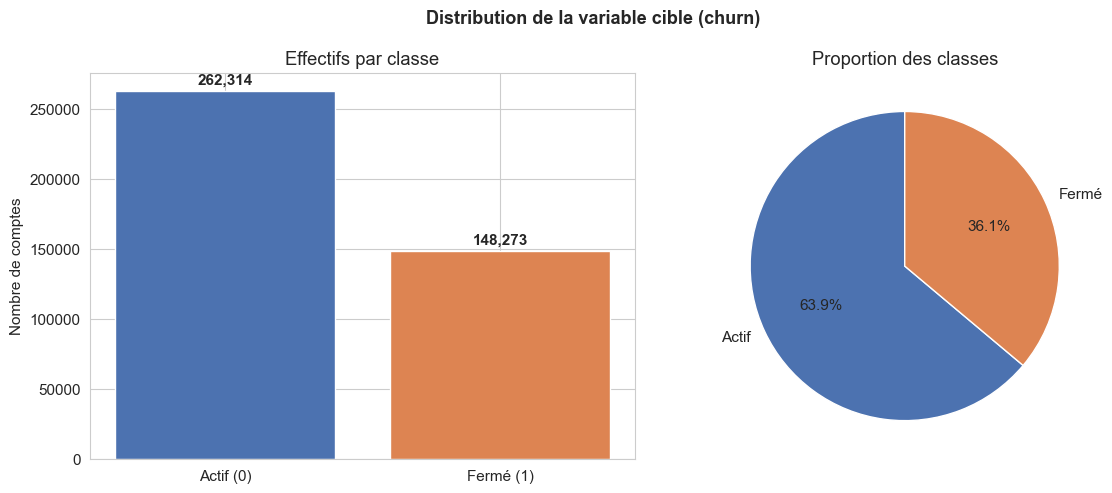

Ratio déséquilibre (majoritaire / minoritaire) : 1.77 : 1


In [9]:
churn_counts = df_ml["churn"].value_counts().sort_index()
churn_pct = df_ml["churn"].value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(["Actif (0)", "Fermé (1)"], churn_counts.values, color=["#4C72B0", "#DD8452"])
axes[0].set_title("Effectifs par classe")
axes[0].set_ylabel("Nombre de comptes")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 5000, f"{v:,}", ha="center", fontweight="bold")

axes[1].pie(churn_pct.values, labels=["Actif", "Fermé"], autopct="%1.1f%%",
            colors=["#4C72B0", "#DD8452"], startangle=90)
axes[1].set_title("Proportion des classes")

plt.suptitle("Distribution de la variable cible (churn)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Ratio déséquilibre (majoritaire / minoritaire) : "
      f"{churn_counts.max() / churn_counts.min():.2f} : 1")

**Interprétation** : la classe minoritaire (**churn = 1**, comptes fermés) représente
environ 36% du jeu de données = un déséquilibre **modéré**

### 2.2 Distribution des variables numériques

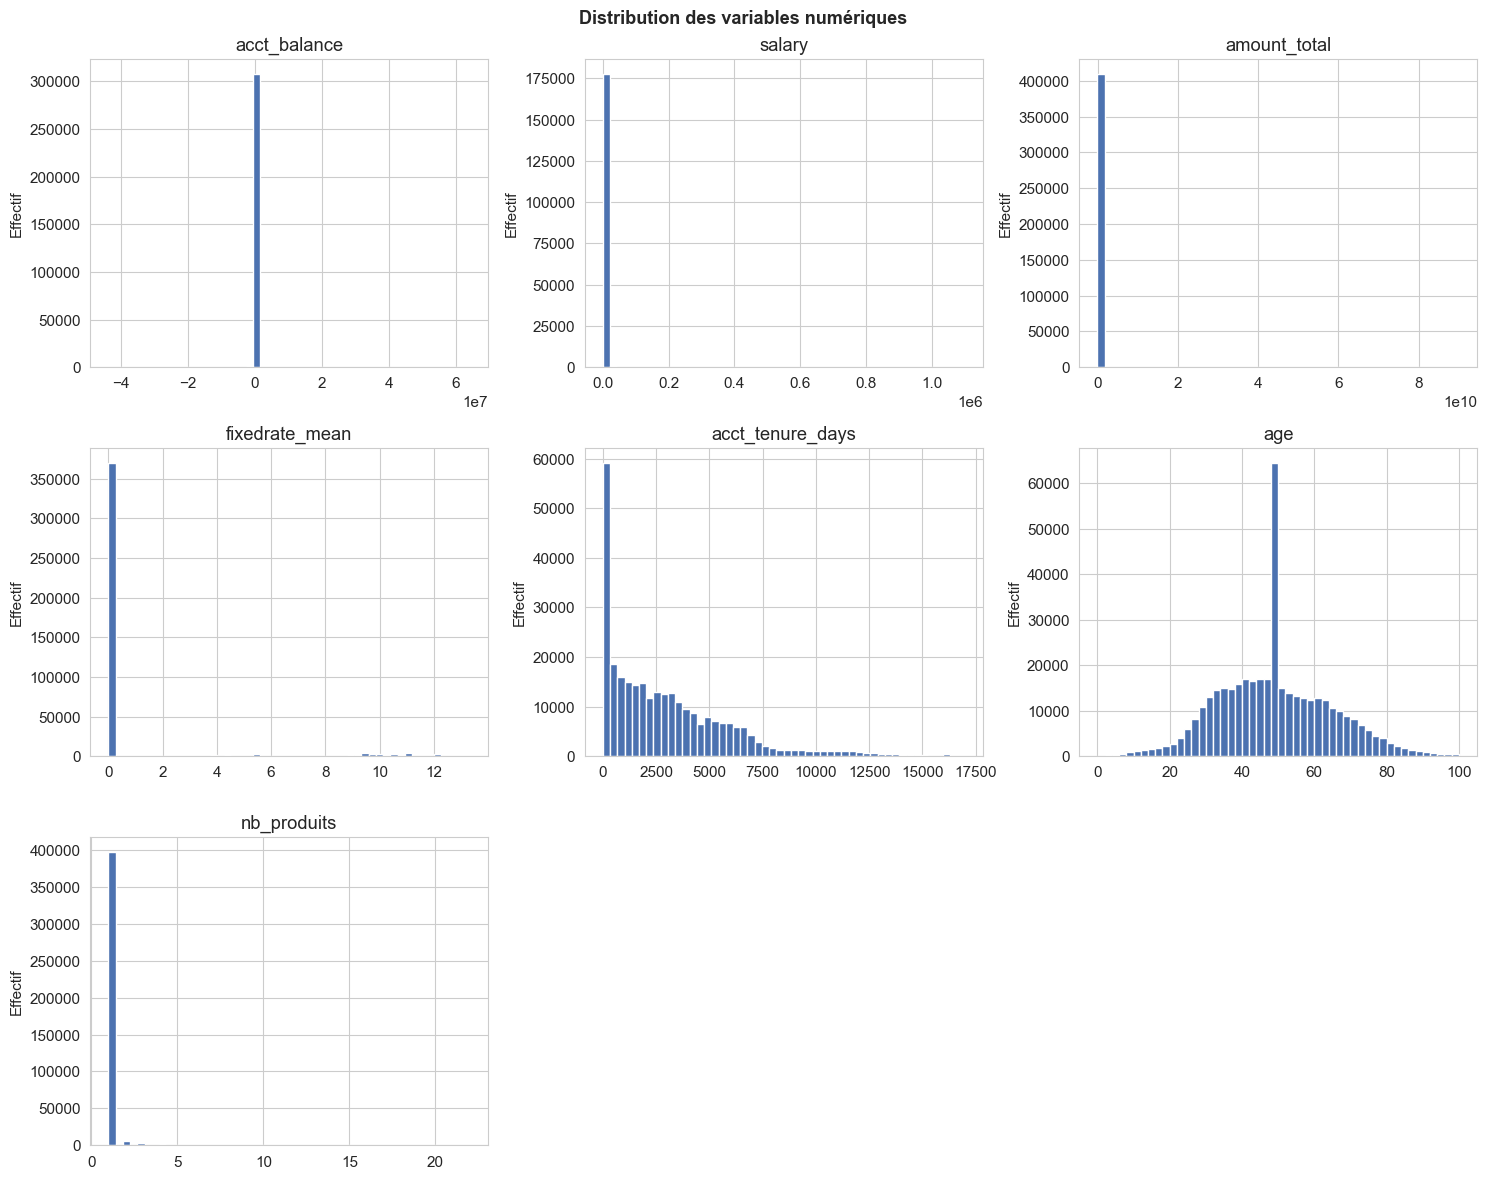

In [10]:
num_features = ["acct_balance", "salary", "amount_total", "fixedrate_mean",
                "acct_tenure_days", "age", "nb_produits"]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(num_features):
    data = df_ml[col].dropna()
    axes[i].hist(data, bins=50, color="#4C72B0", edgecolor="white")
    axes[i].set_title(col)
    axes[i].set_ylabel("Effectif")
for ax in axes[len(num_features):]:
    ax.axis("off")
plt.suptitle("Distribution des variables numériques", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Standardisation nécéssaire vu la différence de l'échelle

### 2.3 Matrice de corrélation

Utile pour la feature selection

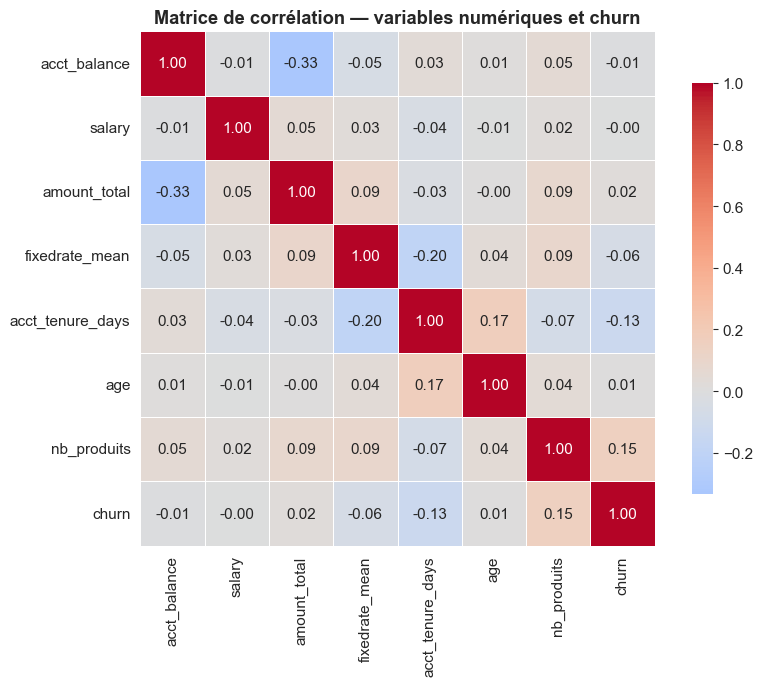

In [11]:
corr_cols = num_features + ["churn"]
corr_matrix = df_ml[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Matrice de corrélation — variables numériques et churn", fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Sélection des variables (Feature Selection)

 **fuite d'information** (data leakage : la variable contient déjà, directement ou indirectement, le résultat qu'on essaie de prédire)
### 3.1 Variables exclues — fuite d'information (data leakage)

| Variable | Raison de l'exclusion |
|---|---|
| `ACCT_CLOSE_DATE` | N'existe **qu'après** la fermeture du compte — l'utiliser reviendrait à donner au modèle une information qui ne serait jamais disponible au moment réel de la prédiction |
| `CLOSURE_REASON` / `closure_key` | Motif de clôture : n'existe que pour les comptes déjà fermés, c'est un label post-churn, pas un prédicteur |
| `ACCOUNT_STATUS` | C'est la variable utilisée pour **construire** `churn` elle-même (`churn = 1 si ACCOUNT_STATUS == 'Closed'`) — l'inclure donnerait au modèle la réponse littérale |

### 3.2 Variables exclues — identifiants sans valeur prédictive

| Variable | Raison de l'exclusion |
|---|---|
| `account_key`, `ACCOUNT_NO` | Identifiant unique par compte — aucune généralisation possible, un modèle qui apprendrait sur ces valeurs ferait du sur-apprentissage pur |
| `client_key`, `CUSTOMER_NO` | Idem, au niveau client |
| `branch_key` | Conservé sous sa forme catégorielle `BRANCH` (141 agences) plutôt que sa clé technique, qui n'a pas de sens ordonné |

### 3.3 Variables exclues — redondance ou cardinalité excessive

| Variable | Raison de l'exclusion |
|---|---|
| `ACCOUNT_TYPE_DESC` | **149 catégories distinctes**, strictement redondante avec `ACCOUNT_CATEGORY` (même cardinalité, l'une est juste le libellé textuel de l'autre) — un One-Hot Encoding sur 149 catégories gonflerait le nombre de colonnes de façon disproportionnée pour un gain d'information nul par rapport à `ACCOUNT_CATEGORY` |
| `ACCOUNT_CATEGORY` | Conservée en numérique mais **traitée comme catégorie à cardinalité élevée** encodage spécifique (pas de One-Hot direct) |
| `NATIONALITY`, `RESIDENCE` | Quasi-constantes (>93% de la même valeur 'TN', vérifié dans l'EDA) — une variable avec une variance quasi nulle n'apporte (quasiment) aucun pouvoir de séparation aux modèles |

### 3.4 Variables conservées

| Variable | Type | Justification |
|---|---|---|
| `acct_balance`, `salary`, `amount_total`, `fixedrate_mean` | Numérique | Mesures financières directement liées au profil du compte/client |
| `acct_tenure_days`, `age`, `nb_produits`, `nb_accounts_per_client` | Numérique | Ancienneté et engagement — souvent prédictifs du churn dans la littérature (un client récent ou peu engagé est statistiquement plus volatile) |
| `MARITAL_STATUS`, `NATURE_CLIENT`, `PARTYCLASS`, `SCORE_KYC`, `COMPLETED_FILE` | Catégorielle (faible cardinalité) | Profil démographique et réglementaire du client |
| `CURRENCY`, `BRANCH` | Catégorielle (cardinalité modérée) | Devise et agence — `BRANCH` a 141 valeurs, gérable en One-Hot mais à surveiller (section 5) |
| `LOB` | Catégorielle (déjà numérique, faible cardinalité réelle) | Segment commercial du client (Retail, Corporate...), décodable via `dim_TARGET.xlsx` |

In [12]:
# Colonnes explicitement exclues, avec leur raison (pour traçabilité dans le notebook)
colonnes_exclues = {
    "account_key": "identifiant", "client_key": "identifiant", "branch_key": "identifiant (remplacé par BRANCH)",
    "ACCOUNT_TYPE_DESC": "redondant avec ACCOUNT_CATEGORY, cardinalité excessive (149)",
}

features_numeriques = [
    "acct_balance", "salary", "amount_total", "fixedrate_mean",
    "acct_tenure_days", "age", "nb_produits", "nb_accounts_per_client",
]
features_categorielles = [
    "ACCOUNT_CATEGORY", "CURRENCY", "MARITAL_STATUS", "NATURE_CLIENT",
    "PARTYCLASS", "SCORE_KYC", "COMPLETED_FILE", "BRANCH", "LOB",
]

print(f"Variables numériques retenues   ({len(features_numeriques)}) : {features_numeriques}")
print(f"Variables catégorielles retenues ({len(features_categorielles)}) : {features_categorielles}")
print(f"\nCardinalité des variables catégorielles :")
for col in features_categorielles:
    print(f"  {col:20s} : {df_ml[col].nunique()} valeurs uniques")

Variables numériques retenues   (8) : ['acct_balance', 'salary', 'amount_total', 'fixedrate_mean', 'acct_tenure_days', 'age', 'nb_produits', 'nb_accounts_per_client']
Variables catégorielles retenues (9) : ['ACCOUNT_CATEGORY', 'CURRENCY', 'MARITAL_STATUS', 'NATURE_CLIENT', 'PARTYCLASS', 'SCORE_KYC', 'COMPLETED_FILE', 'BRANCH', 'LOB']

Cardinalité des variables catégorielles :
  ACCOUNT_CATEGORY     : 149 valeurs uniques
  CURRENCY             : 19 valeurs uniques
  MARITAL_STATUS       : 6 valeurs uniques
  NATURE_CLIENT        : 6 valeurs uniques
  PARTYCLASS           : 5 valeurs uniques
  SCORE_KYC            : 5 valeurs uniques
  COMPLETED_FILE       : 2 valeurs uniques
  BRANCH               : 141 valeurs uniques
  LOB                  : 9 valeurs uniques


## 4. Séparation Features (X) et Cible (y)

In [13]:
y = df_ml["churn"].copy()
X = df_ml[features_numeriques + features_categorielles].copy()

print(f"X : {X.shape[0]:,} lignes x {X.shape[1]} colonnes")
print(f"y : {y.shape[0]:,} valeurs, taux de churn = {y.mean()*100:.1f}%")
X.head()

X : 410,587 lignes x 17 colonnes
y : 410,587 valeurs, taux de churn = 36.1%


,acct_balance,salary,amount_total,fixedrate_mean,acct_tenure_days,age,nb_produits,nb_accounts_per_client,ACCOUNT_CATEGORY,CURRENCY,MARITAL_STATUS,NATURE_CLIENT,PARTYCLASS,SCORE_KYC,COMPLETED_FILE,BRANCH,LOB
0,-10714.347,2725.739,21909200.0,4.5,2346.0,57,2,4,3023.0,TND,M,PPH,Retail,LR,YES,BR114,4
1,0.000,3300.537,0.0,0.0,NaN,66,2,6,3611.0,TND,M,PPH,Retail,LR,YES,BR114,4
2,-113033.101,2725.739,227186154.0,4.5,961.0,57,2,4,3017.0,TND,M,PPH,Retail,LR,YES,BR114,4
3,0.000,2725.739,0.0,0.0,1342.0,57,2,4,1011.0,TND,M,PPH,Retail,LR,YES,BR114,4
4,0.000,3300.537,0.0,0.0,NaN,66,2,6,3611.0,TND,M,PPH,Retail,LR,YES,BR114,4


## 4bis. Traitement des valeurs manquantes résiduelles

**Imputation retenue : la médiane**, pas la moyenne skew élevé sur salary/Acct_balance
### ⚠️ Indicateurs de nullité (`_missing`) : vérifiés individuellement, pas appliqués par défaut
*l'absence* d'une donnée peut elle-même être informative (par exemple, on a
observé dans l'EDA qu'un salaire non déclaré semble corréler légèrement avec le
churn).

In [14]:
cols_avec_nan = ["acct_balance", "salary", "acct_tenure_days"]

print("Vérification : le taux de churn diffère-t-il selon que la donnée est manquante ?")
print("(Un écart proche de 0% ou 100% — au lieu du taux de base ~36% — signale une fuite,")
print(" pas un vrai signal métier.)\n")

for col in cols_avec_nan:
    mask = df_ml[col].isna()
    taux_si_manquant = df_ml.loc[mask, "churn"].mean() * 100
    taux_si_renseigne = df_ml.loc[~mask, "churn"].mean() * 100
    print(f"{col:20s} : {mask.sum():>7,} manquants | "
          f"taux churn si manquant = {taux_si_manquant:5.1f}% | "
          f"si renseigné = {taux_si_renseigne:5.1f}%")

Vérification : le taux de churn diffère-t-il selon que la donnée est manquante ?
(Un écart proche de 0% ou 100% — au lieu du taux de base ~36% — signale une fuite,
 pas un vrai signal métier.)

acct_balance         : 100,485 manquants | taux churn si manquant = 100.0% | si renseigné =  15.4%
salary               : 231,753 manquants | taux churn si manquant =  37.3% | si renseigné =  34.6%
acct_tenure_days     : 118,818 manquants | taux churn si manquant = 100.0% | si renseigné =  10.1%


### Résultat de la vérification

| Colonne | Taux de churn si manquant | Diagnostic |
|---|---|---|
| `acct_balance` | **100%** | 🔴 Fuite confirmée — cause : la neutralisation de `ACCT_OPENING_DATE` dans l'ETL (`01_etl/etl_pipeline/clean.py`) ne s'applique qu'à des comptes déjà fermés, rendant cette nullité un proxy quasi-parfait du label |
| `acct_tenure_days` | **100%** | 🔴 Fuite confirmée — même cause exacte que `acct_balance` (les deux dépendent de `ACCT_OPENING_DATE`) |
| `salary` | ~37% (proche du taux de base 36,1%) | ✅ Signal légitime — l'absence de salaire déclaré est indépendante du statut du compte, conforme à l'observation déjà faite dans l'EDA |

**Décision** : on ne crée l'indicateur de nullité **que pour `salary`**, dont
l'absence reflète un vrai comportement (non-déclaration), pas un artefact de
nettoyage. Les deux autres indicateurs ne sont pas créés — leur inclusion
donnerait au modèle un accès quasi direct au label sous une autre forme, ce qui
fausserait toutes les métriques de performance des sections suivantes sans qu'on
puisse s'y fier en production (au moment réel de la prédiction, sur un compte
encore actif, cette "fuite" n'existerait simplement pas).

In [15]:
X["salary_missing"] = X["salary"].isna().astype(int)

for col in cols_avec_nan:
    X[col] = X[col].fillna(X[col].median())

print("Indicateur de nullité créé : ['salary_missing'] uniquement.")
print("(acct_balance_missing et acct_tenure_days_missing volontairement NON créés — voir ci-dessus)")
print("\nValeurs manquantes restantes :", X.isna().sum().sum())

Indicateur de nullité créé : ['salary_missing'] uniquement.
(acct_balance_missing et acct_tenure_days_missing volontairement NON créés — voir ci-dessus)



Valeurs manquantes restantes : 0


## 5. Encodage des variables catégorielles
* One hot encoder avant le Split 
* Encodage par fréquence aprés le Split

In [16]:
features_onehot = ["MARITAL_STATUS", "NATURE_CLIENT", "PARTYCLASS", "SCORE_KYC",
                    "COMPLETED_FILE", "CURRENCY", "LOB"]
features_frequence = ["ACCOUNT_CATEGORY", "BRANCH"]

print("Cardinalité des variables encodées en One-Hot :")
for col in features_onehot:
    print(f"  {col:18s} : {X[col].nunique()} catégories")
print("\nCardinalité des variables encodées par fréquence :")
for col in features_frequence:
    print(f"  {col:18s} : {X[col].nunique()} catégories")

Cardinalité des variables encodées en One-Hot :
  MARITAL_STATUS     : 6 catégories
  NATURE_CLIENT      : 6 catégories
  PARTYCLASS         : 5 catégories
  SCORE_KYC          : 5 catégories
  COMPLETED_FILE     : 2 catégories
  CURRENCY           : 19 catégories
  LOB                : 9 catégories

Cardinalité des variables encodées par fréquence :
  ACCOUNT_CATEGORY   : 149 catégories
  BRANCH             : 141 catégories


In [17]:
X_encoded = pd.get_dummies(X, columns=features_onehot, drop_first=True)

print(f"X avant encodage     : {X.shape[1]} colonnes")
print(f"X après One-Hot       : {X_encoded.shape[1]} colonnes")
print(f"(ACCOUNT_CATEGORY et BRANCH restent à encoder par fréquence après le split)")

X avant encodage     : 18 colonnes
X après One-Hot       : 56 colonnes
(ACCOUNT_CATEGORY et BRANCH restent à encoder par fréquence après le split)


## 6. Mise à l'échelle (Feature Scaling)

## 7. Découpage Train / Test

### Ratio retenu : 80% / 20%

### Stratification

`stratify=y` garantit que la proportion de comptes fermés est **identique** dans le
train et le test (≈36,1% dans les deux) 

### Graine aléatoire fixe

`random_state=42`  garantit que ce notebook produit **exactement les mêmes**
résultats à chaque exécution, condition nécessaire à la reproductibilité demandée.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train : {X_train.shape[0]:,} comptes ({X_train.shape[0]/len(X_encoded)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]:,} comptes ({X_test.shape[0]/len(X_encoded)*100:.0f}%)")
print(f"\nTaux de churn train : {y_train.mean()*100:.2f}%")
print(f"Taux de churn test  : {y_test.mean()*100:.2f}%")

Train : 328,469 comptes (80%)
Test  : 82,118 comptes (20%)

Taux de churn train : 36.11%
Taux de churn test  : 36.11%


### Encodage par fréquence — ajusté uniquement sur le train

Comme annoncé en section 5, l'encodage par fréquence de `ACCOUNT_CATEGORY` et
`BRANCH` est calculé **uniquement à partir de `X_train`**, puis appliqué tel quel à
`X_test`. Si une catégorie du test n'a jamais été vue dans le train (rare mais
possible), elle reçoit la fréquence `0` plutôt que de faire échouer le pipeline.

In [19]:
for col in features_frequence:
    freq_map = X_train[col].value_counts(normalize=True)
    X_train[col] = X_train[col].map(freq_map)
    X_test[col] = X_test[col].map(freq_map).fillna(0)  # catégorie jamais vue au train -> 0

print("Encodage par fréquence appliqué sur :", features_frequence)
print(X_train[features_frequence].head())

Encodage par fréquence appliqué sur : ['ACCOUNT_CATEGORY', 'BRANCH']
        ACCOUNT_CATEGORY    BRANCH
407136          0.017274  0.016199
379775          0.048967  0.008835
318390          0.001160  0.017548
21616           0.004232  0.012376
221094          0.016900  0.008564


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

print("Mise à l'échelle effectuée (ajustée uniquement sur X_train, appliquée à X_test).")
print("\nMoyenne après standardisation (train) :", X_train_scaled.mean().mean().round(4))
print("Écart-type après standardisation (train) :", X_train_scaled.std().mean().round(4))

Mise à l'échelle effectuée (ajustée uniquement sur X_train, appliquée à X_test).

Moyenne après standardisation (train) : 0.0
Écart-type après standardisation (train) : 1.0


## 8. Gestion du déséquilibre de classes


### SMOTE (Synthetic Minority Over-sampling Technique)


Nb : SMOTE s'applique uniquement sur le jeu d'entraînement, jamais sur le jeu de test.

In [21]:
# Demonstration concrete du piege de l'accuracy : un modele "naif" qui predit
# toujours la classe majoritaire.
from sklearn.metrics import accuracy_score

y_pred_naif = np.zeros(len(y_test))  # toujours "actif"
accuracy_naive = accuracy_score(y_test, y_pred_naif)
print(f"Accuracy d'un modèle qui prédit toujours 'Actif' : {accuracy_naive*100:.1f}%")
print("-> Ce chiffre est trompeusement élevé : ce modèle ne détecte JAMAIS un compte "
      "à risque de fermeture, il n'a aucune utilité métier malgré une accuracy correcte.")

Accuracy d'un modèle qui prédit toujours 'Actif' : 63.9%
-> Ce chiffre est trompeusement élevé : ce modèle ne détecte JAMAIS un compte à risque de fermeture, il n'a aucune utilité métier malgré une accuracy correcte.


In [22]:
from imblearn.over_sampling import SMOTE

print(f"Avant SMOTE — train : {len(y_train):,} lignes, "
      f"{y_train.sum():,} fermés ({y_train.mean()*100:.1f}%)")

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Après SMOTE — train  : {len(y_train_smote):,} lignes, "
      f"{y_train_smote.sum():,} fermés ({y_train_smote.mean()*100:.1f}%)")
print(f"\nJeu de test inchangé : {len(y_test):,} lignes, "
      f"taux de churn réel = {y_test.mean()*100:.1f}% (NE DOIT PAS être modifié par SMOTE).")

Avant SMOTE — train : 328,469 lignes, 118,618 fermés (36.1%)
Après SMOTE — train  : 419,702 lignes, 209,851 fermés (50.0%)

Jeu de test inchangé : 82,118 lignes, taux de churn réel = 36.1% (NE DOIT PAS être modifié par SMOTE).


Les deux jeux d'entraînement (`X_train_scaled`/`y_train` sans rééquilibrage, et
`X_train_smote`/`y_train_smote` rééquilibré) sont conservés en parallèle — chaque
modèle de la section 10 sera entraîné sur les deux versions pour mesurer concrètement
l'effet de SMOTE, comme demandé.

## 9. Modèle de référence (Baseline) — Régression Logistique


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, ConfusionMatrixDisplay,
)
import time

log_reg = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)

debut = time.time()
log_reg.fit(X_train_scaled, y_train)
temps_entrainement = time.time() - debut

y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print(f"Régression logistique entraînée en {temps_entrainement:.2f} secondes.")

Régression logistique entraînée en 1.60 secondes.


### Métriques d'évaluation 

$$\text{Precision} = \frac{TP}{TP + FP} \qquad
\text{Recall} = \frac{TP}{TP + FN} \qquad
F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

In [24]:
def afficher_metriques(y_true, y_pred, y_proba, nom_modele):
    """Calcule et affiche les métriques standard pour un modèle donné."""
    metrics = {
        "Modèle": nom_modele,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan,
    }
    print(f"--- {nom_modele} ---")
    for k, v in metrics.items():
        if k != "Modèle":
            print(f"  {k:12s} : {v:.4f}")
    return metrics


metrics_log_reg = afficher_metriques(y_test, y_pred, y_proba, "Régression Logistique (baseline)")

--- Régression Logistique (baseline) ---
  Accuracy     : 0.7991
  Precision    : 0.7669
  Recall       : 0.6376
  F1-score     : 0.6963
  ROC-AUC      : 0.8015


### Matrice de confusion

La matrice de confusion détaille les quatre cas possibles (vrai/faux positif/négatif)
— elle donne une vision plus complète qu'un seul chiffre agrégé, et permet de voir
concrètement de quel côté le modèle se trompe le plus.

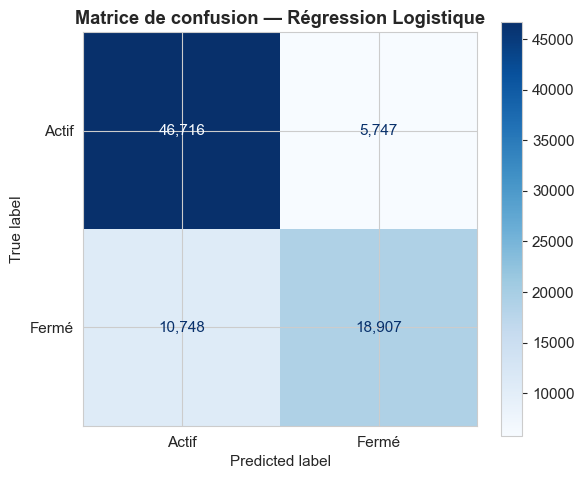

Vrais négatifs  (actifs correctement prédits)  : 46,716
Faux positifs   (actifs prédits 'fermé' à tort) : 5,747
Faux négatifs   (fermetures non détectées)      : 10,748
Vrais positifs  (fermetures correctement prédites) : 18,907


In [25]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Actif", "Fermé"])
disp.plot(ax=ax, cmap="Blues", values_format=",d")
ax.set_title("Matrice de confusion — Régression Logistique", fontweight="bold")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Vrais négatifs  (actifs correctement prédits)  : {tn:,}")
print(f"Faux positifs   (actifs prédits 'fermé' à tort) : {fp:,}")
print(f"Faux négatifs   (fermetures non détectées)      : {fn:,}")
print(f"Vrais positifs  (fermetures correctement prédites) : {tp:,}")

### Courbe ROC et ROC-AUC

La courbe ROC (Receiver Operating Characteristic) trace le taux de vrais positifs
contre le taux de faux positifs, pour tous les seuils de décision possibles (pas
seulement 0,5) 
L'aire sous cette courbe (**AUC**, Area Under Curve) résume cette
performance en un seul chiffre entre 0,5 (pas mieux que le hasard) et 1 (parfait).

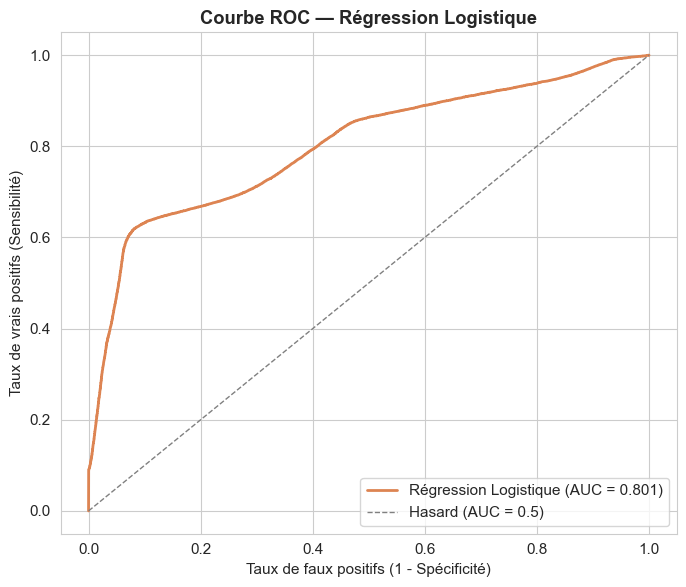

In [26]:
fpr, tpr, seuils = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="#DD8452", lw=2, label=f"Régression Logistique (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Hasard (AUC = 0.5)")
plt.xlabel("Taux de faux positifs (1 - Spécificité)")
plt.ylabel("Taux de vrais positifs (Sensibilité)")
plt.title("Courbe ROC — Régression Logistique", fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 10. Entraînement de plusieurs modèles de classification
 **avec et sans SMOTE** 

In [27]:
def entrainer_evaluer(modele, X_tr, y_tr, X_te, y_te, nom_modele):
    """Entraîne un modèle, l'évalue, affiche ses métriques et sa matrice de
    confusion, et retourne un dict de résultats pour le tableau comparatif
    (section 11).
    """
    debut = time.time()
    modele.fit(X_tr, y_tr)
    temps = time.time() - debut

    y_pred = modele.predict(X_te)
    y_proba = modele.predict_proba(X_te)[:, 1] if hasattr(modele, "predict_proba") else None

    resultats = {
        "Modèle": nom_modele,
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred, zero_division=0),
        "Recall": recall_score(y_te, y_pred, zero_division=0),
        "F1-score": f1_score(y_te, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_te, y_proba) if y_proba is not None else np.nan,
        "Temps (s)": temps,
    }

    print(f"--- {nom_modele} ---")
    for k, v in resultats.items():
        if k not in ("Modèle",):
            print(f"  {k:12s} : {v:.4f}" if isinstance(v, float) else f"  {k:12s} : {v}")

    return resultats, y_pred, y_proba


resultats_tous_modeles = []  

### 10.1 K-Nearest Neighbors (KNN)
Sous-échantillon du jeu de TEST pour KNN uniquement (sensible à la taille de l'échantillion)

Grid search

In [28]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, train_test_split

# --- Échantillon réduit pour accélérer le Grid Search ---
N_GRIDSEARCH_KNN = 10000  # à ajuster selon la taille de ton dataset et le temps dispo

X_train_sample_knn, _, y_train_sample_knn, _ = train_test_split(
    X_train_scaled, y_train,
    train_size=N_GRIDSEARCH_KNN,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print(f"Grid Search KNN sur un sous-échantillon d'entraînement de {N_GRIDSEARCH_KNN:,} comptes "
      f"(sur {len(X_train_scaled):,} disponibles).")

# --- Grid Search ---
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search_knn.fit(X_train_sample_knn, y_train_sample_knn)

print("Meilleurs hyperparamètres KNN :", grid_search_knn.best_params_)
print("Meilleur score CV (f1) :", grid_search_knn.best_score_)

best_knn = grid_search_knn.best_estimator_

Grid Search KNN sur un sous-échantillon d'entraînement de 10,000 comptes (sur 328,469 disponibles).
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Meilleurs hyperparamètres KNN : {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
Meilleur score CV (f1) : 0.7811035092024378


In [29]:
from sklearn.neighbors import KNeighborsClassifier

N_TEST_KNN = 10000
X_test_scaled_knn, _, y_test_knn, _ = train_test_split(
    X_test_scaled, y_test, train_size=N_TEST_KNN, random_state=RANDOM_STATE, stratify=y_test
)
print(f"KNN évalué sur un sous-échantillon de test de {N_TEST_KNN:,} comptes "
      f"(sur {len(X_test_scaled):,} disponibles) — voir justification ci-dessus.")

# --- Sans SMOTE ---
res, y_pred_knn, y_proba_knn = entrainer_evaluer(
    best_knn, X_train_scaled, y_train, X_test_scaled_knn, y_test_knn, "KNN (GridSearch, sans SMOTE)"
)
resultats_tous_modeles.append(res)

KNN évalué sur un sous-échantillon de test de 10,000 comptes (sur 82,118 disponibles) — voir justification ci-dessus.


--- KNN (GridSearch, sans SMOTE) ---
  Accuracy     : 0.9250
  Precision    : 0.8920
  Recall       : 0.9014
  F1-score     : 0.8967
  ROC-AUC      : 0.9602
  Temps (s)    : 1.5877


In [30]:
# --- Avec SMOTE ---
res, y_pred_knn_sm, y_proba_knn_sm = entrainer_evaluer(
    best_knn, X_train_smote, y_train_smote, X_test_scaled_knn, y_test_knn, "KNN (GridSearch, avec SMOTE)"
)
resultats_tous_modeles.append(res)

--- KNN (GridSearch, avec SMOTE) ---
  Accuracy     : 0.9148
  Precision    : 0.8564
  Recall       : 0.9180
  F1-score     : 0.8861
  ROC-AUC      : 0.9578
  Temps (s)    : 1.3503


### 10.2 Decision Tree

Grid search

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# --- Grid Search pour Decision Tree ---
param_grid_dt = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

grid_search_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid_dt,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search_dt.fit(X_train, y_train)

print("Meilleurs hyperparamètres Decision Tree :", grid_search_dt.best_params_)
print("Meilleur score CV (f1) :", grid_search_dt.best_score_)

best_dt = grid_search_dt.best_estimator_

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Meilleurs hyperparamètres Decision Tree : {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 2}
Meilleur score CV (f1) : 0.9442367656071975


In [32]:
#Sans smote
res, y_pred_dt, y_proba_dt = entrainer_evaluer(
    best_dt, X_train, y_train, X_test, y_test, "Arbre de Décision (GridSearch, sans SMOTE)"
)
resultats_tous_modeles.append(res)

--- Arbre de Décision (GridSearch, sans SMOTE) ---
  Accuracy     : 0.9613
  Precision    : 0.9810
  Recall       : 0.9104
  F1-score     : 0.9444
  ROC-AUC      : 0.9744
  Temps (s)    : 9.1731


In [33]:
#Avec Smote
res, y_pred_dt_sm, y_proba_dt_sm = entrainer_evaluer(
    best_dt, X_train_smote, y_train_smote, X_test, y_test, "Arbre de Décision (GridSearch, avec SMOTE)"
)
resultats_tous_modeles.append(res)

--- Arbre de Décision (GridSearch, avec SMOTE) ---
  Accuracy     : 0.3611
  Precision    : 0.3611
  Recall       : 1.0000
  F1-score     : 0.5306
  ROC-AUC      : 0.4087
  Temps (s)    : 11.2752


Pour les modeles sans scaling, on reconstruit une version SMOTE non standardisee

In [35]:
from imblearn.over_sampling import SMOTE
smote_unscaled = SMOTE(random_state=RANDOM_STATE)
X_train_smote_raw, y_train_smote_raw = smote_unscaled.fit_resample(X_train, y_train)

res, y_pred_dt_sm, y_proba_dt_sm = entrainer_evaluer(
    best_dt, X_train_smote_raw, y_train_smote_raw, X_test, y_test,
    "Arbre de Décision (GridSearch, avec SMOTE)"
)
resultats_tous_modeles.append(res)

--- Arbre de Décision (GridSearch, avec SMOTE) ---
  Accuracy     : 0.9601
  Precision    : 0.9808
  Recall       : 0.9072
  F1-score     : 0.9425
  ROC-AUC      : 0.9737
  Temps (s)    : 8.9066


### 10.3 Random Forest

Randomizedsearch cv

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split

# --- Échantillon pour accélérer la recherche ---
N_RANDOMSEARCH_RF = 20000  # à ajuster selon la taille de ton dataset

X_train_sample_rf, _, y_train_sample_rf, _ = train_test_split(
    X_train, y_train,
    train_size=N_RANDOMSEARCH_RF,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print(f"Randomized Search Random Forest sur un sous-échantillon de {N_RANDOMSEARCH_RF:,} comptes "
      f"(sur {len(X_train):,} disponibles).")

# --- Espace de recherche (peut être plus large qu'avec GridSearch) ---
param_dist_rf = {
    'n_estimators': [100, 150, 200, 250, 300, 400, 500],
    'max_depth': [5, 10, 15, 20, 25, 30, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2', None]
}

random_search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=30,              # nombre de combinaisons testées (ajustable selon le temps dispo)
    scoring='f1',
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=2
)

random_search_rf.fit(X_train_sample_rf, y_train_sample_rf)

print("Meilleurs hyperparamètres Random Forest :", random_search_rf.best_params_)
print("Meilleur score CV (f1) :", random_search_rf.best_score_)

best_rf = random_search_rf.best_estimator_

Randomized Search Random Forest sur un sous-échantillon de 20,000 comptes (sur 328,469 disponibles).
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Meilleurs hyperparamètres Random Forest : {'n_estimators': 500, 'min_samples_split': 15, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 15}
Meilleur score CV (f1) : 0.9436014551180529


In [37]:
from sklearn.ensemble import RandomForestClassifier

res, y_pred_rf, y_proba_rf = entrainer_evaluer(
    best_rf, X_train, y_train, X_test, y_test, "Random Forest (RandomizedSearch, sans SMOTE)"
)
resultats_tous_modeles.append(res)

--- Random Forest (RandomizedSearch, sans SMOTE) ---
  Accuracy     : 0.9642
  Precision    : 0.9933
  Recall       : 0.9070
  F1-score     : 0.9482
  ROC-AUC      : 0.9821
  Temps (s)    : 436.6240


In [ ]:
res, y_pred_rf_sm, y_proba_rf_sm = entrainer_evaluer(
    best_rf, X_train_smote_raw, y_train_smote_raw, X_test, y_test, "Random Forest (RandomizedSearch, avec SMOTE)"
)
resultats_tous_modeles.append(res)

### 10.4 SVM

Randomized search cv

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

param_dist_svm = {
    'C': loguniform(1e-2, 1e3),
    'gamma': loguniform(1e-4, 1e1),
    'kernel': ['rbf']  # tu peux ajouter 'linear', 'poly' si tu veux comparer
}

random_search_svm = RandomizedSearchCV(
    estimator=SVC(probability=True, random_state=RANDOM_STATE),
    param_distributions=param_dist_svm,
    n_iter=20,             # à ajuster selon le temps dispo — SVM est lent
    scoring='f1',
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=2
)

random_search_svm.fit(X_train_svm, y_train_svm)  # ton sous-échantillon existant pour SVM

print("Meilleurs hyperparamètres SVM :", random_search_svm.best_params_)
print("Meilleur score CV (f1) :", random_search_svm.best_score_)

best_svm = random_search_svm.best_estimator_

In [ ]:
from sklearn.svm import SVC

# Sous-échantillon stratifié pour rendre l'entraînement praticable (voir note ci-dessus) :
# le SVM à noyau RBF a une complexité qui croît très rapidement avec le nombre de lignes.
n_echantillon_svm = 20000
X_train_svm, _, y_train_svm, _ = train_test_split(
    X_train_scaled, y_train, train_size=n_echantillon_svm,
    random_state=RANDOM_STATE, stratify=y_train,
)
print(f"SVM entraîné sur un sous-échantillon de {n_echantillon_svm:,} comptes "
      f"(sur {len(X_train_scaled):,} disponibles) — voir justification ci-dessus.")

smote_svm = SMOTE(random_state=RANDOM_STATE)
X_train_svm_sm, y_train_svm_sm = smote_svm.fit_resample(X_train_svm, y_train_svm)

res, y_pred_svm_sm, y_proba_svm_sm = entrainer_evaluer(
    best_svm, X_train_svm_sm, y_train_svm_sm, X_test_scaled, y_test,
    "SVM (RandomizedSearch, avec SMOTE, sous-échantillon)"
)
resultats_tous_modeles.append(res)

SVM entraîné sur un sous-échantillon de 20,000 comptes (sur 328,469 disponibles) — voir justification ci-dessus.


--- SVM (sans SMOTE, sous-échantillon) ---
  Accuracy     : 0.8035
  Precision    : 0.7825
  Recall       : 0.6314
  F1-score     : 0.6989
  ROC-AUC      : 0.8469
  Temps (s)    : 86.4851


In [ ]:
smote_svm = SMOTE(random_state=RANDOM_STATE)
X_train_svm_sm, y_train_svm_sm = smote_svm.fit_resample(X_train_svm, y_train_svm)

res, y_pred_svm_sm, y_proba_svm_sm = entrainer_evaluer(
    best_svm, X_train_svm_sm, y_train_svm_sm, X_test_scaled, y_test,
    "SVM (RandomizedSearch, avec SMOTE, sous-échantillon)"
)
resultats_tous_modeles.append(res)

--- SVM (avec SMOTE, sous-échantillon) ---
  Accuracy     : 0.8015
  Precision    : 0.7571
  Recall       : 0.6632
  F1-score     : 0.7071
  ROC-AUC      : 0.8513
  Temps (s)    : 135.5537


### 10.5 XGBoost

Grid search

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import uniform, randint

# --- Échantillon pour accélérer la recherche ---
N_RANDOMSEARCH_XGB = 20000  # à ajuster selon la taille de ton dataset

X_train_sample_xgb, _, y_train_sample_xgb, _ = train_test_split(
    X_train, y_train,
    train_size=N_RANDOMSEARCH_XGB,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print(f"Randomized Search XGBoost sur un sous-échantillon de {N_RANDOMSEARCH_XGB:,} comptes "
      f"(sur {len(X_train):,} disponibles).")

# --- Espace de recherche ---
param_dist_xgb = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),          # entre 0.6 et 1.0
    'colsample_bytree': uniform(0.6, 0.4),   # entre 0.6 et 1.0
    'gamma': uniform(0, 5),
    'min_child_weight': randint(1, 10)
}

random_search_xgb = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1),
    param_distributions=param_dist_xgb,
    n_iter=30,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=2
)

random_search_xgb.fit(X_train_sample_xgb, y_train_sample_xgb)

print("Meilleurs hyperparamètres XGBoost :", random_search_xgb.best_params_)
print("Meilleur score CV (f1) :", random_search_xgb.best_score_)

best_xgb = random_search_xgb.best_estimator_

In [ ]:
res, y_pred_xgb, y_proba_xgb = entrainer_evaluer(
    best_xgb, X_train, y_train, X_test, y_test, "XGBoost (RandomizedSearch, sans SMOTE)"
)
resultats_tous_modeles.append(res)

--- XGBoost (sans SMOTE) ---
  Accuracy     : 0.9631
  Precision    : 0.9931
  Recall       : 0.9040
  F1-score     : 0.9465
  ROC-AUC      : 0.9823
  Temps (s)    : 11.9967


In [ ]:
res, y_pred_xgb_sm, y_proba_xgb_sm = entrainer_evaluer(
    best_xgb, X_train_smote_raw, y_train_smote_raw, X_test, y_test, "XGBoost (RandomizedSearch, avec SMOTE)"
)
resultats_tous_modeles.append(res)

--- XGBoost (avec SMOTE) ---
  Accuracy     : 0.9625
  Precision    : 0.9915
  Recall       : 0.9038
  F1-score     : 0.9456
  ROC-AUC      : 0.9814
  Temps (s)    : 9.6812


### Matrices de confusion 

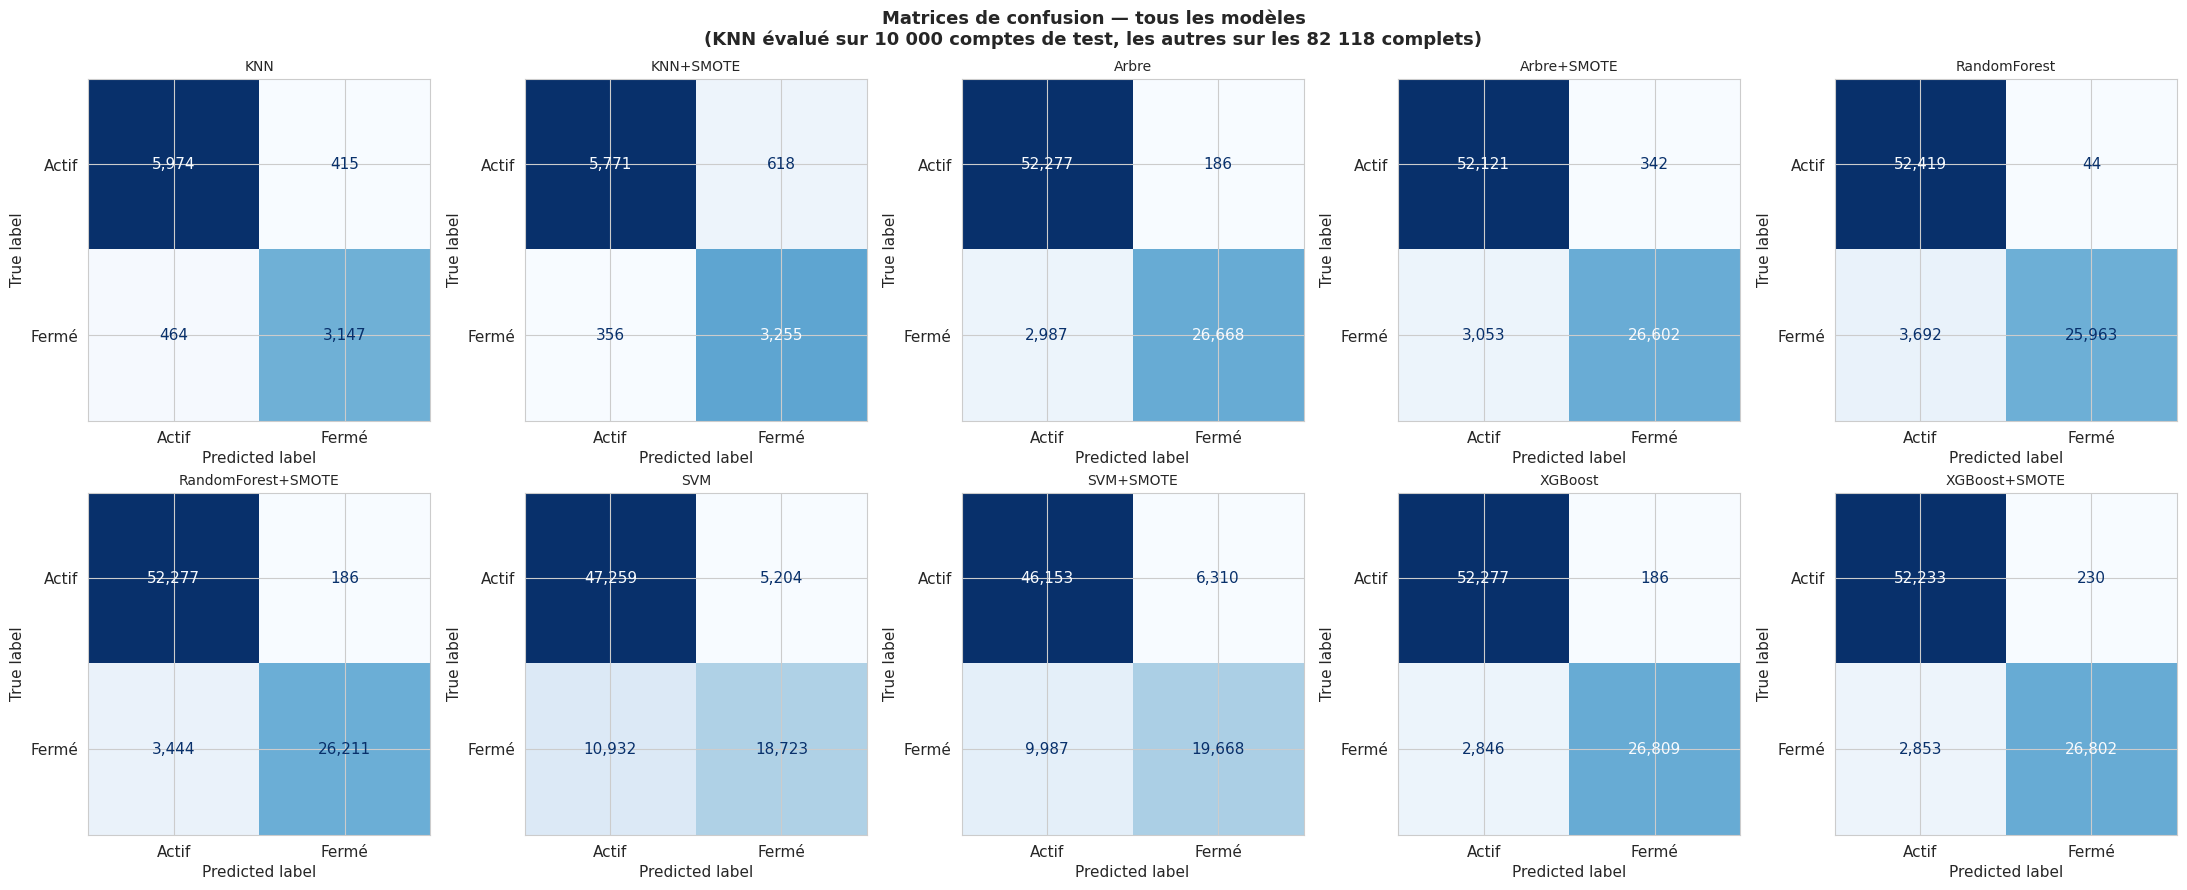

In [ ]:
modeles_pred = {
    "KNN": (y_pred_knn, y_test_knn), "KNN+SMOTE": (y_pred_knn_sm, y_test_knn),
    "Arbre": (y_pred_dt, y_test), "Arbre+SMOTE": (y_pred_dt_sm, y_test),
    "RandomForest": (y_pred_rf, y_test), "RandomForest+SMOTE": (y_pred_rf_sm, y_test),
    "SVM": (y_pred_svm, y_test), "SVM+SMOTE": (y_pred_svm_sm, y_test),
    "XGBoost": (y_pred_xgb, y_test), "XGBoost+SMOTE": (y_pred_xgb_sm, y_test),
}

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()
for i, (nom, (y_p, y_t)) in enumerate(modeles_pred.items()):
    cm_i = confusion_matrix(y_t, y_p)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_i, display_labels=["Actif", "Fermé"])
    disp.plot(ax=axes[i], cmap="Blues", values_format=",d", colorbar=False)
    axes[i].set_title(nom, fontsize=10)
plt.suptitle("Matrices de confusion — tous les modèles\n"
             "(KNN évalué sur 10 000 comptes de test, les autres sur les 82 118 complets)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Courbes ROC vue d'ensemble

Les courbes KNN ne sont pas incluses dans ce graphique 

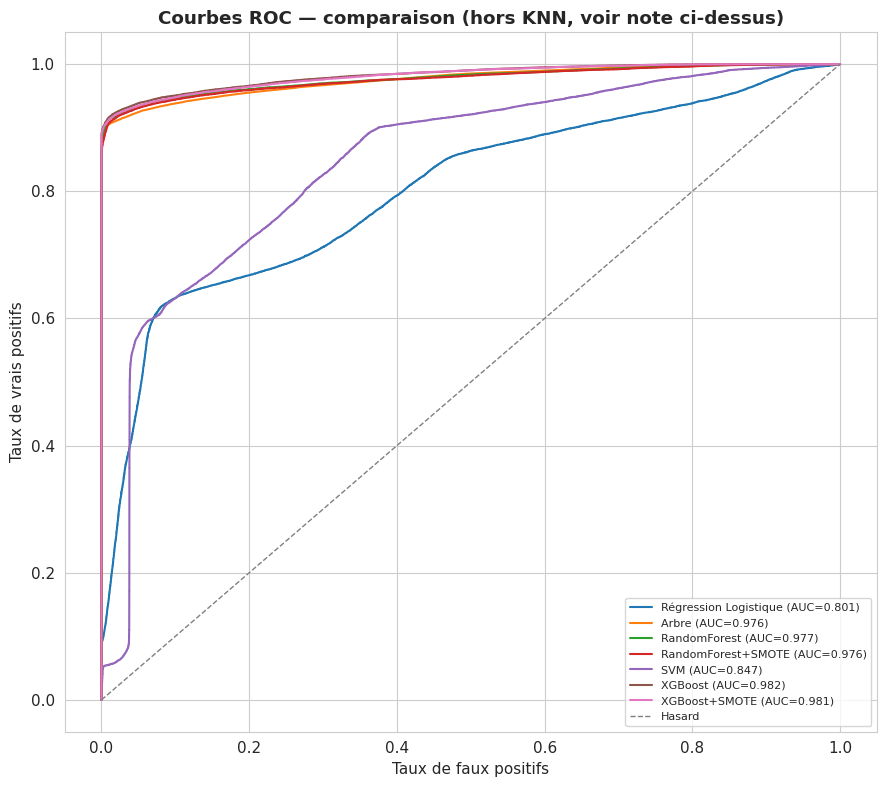

In [ ]:
modeles_proba = {
    "Régression Logistique": y_proba,
    "Arbre": y_proba_dt, "RandomForest": y_proba_rf, "RandomForest+SMOTE": y_proba_rf_sm,
    "SVM": y_proba_svm, "XGBoost": y_proba_xgb, "XGBoost+SMOTE": y_proba_xgb_sm,
}

plt.figure(figsize=(9, 8))
for nom, proba in modeles_proba.items():
    if proba is not None:
        fpr_i, tpr_i, _ = roc_curve(y_test, proba)
        auc_i = roc_auc_score(y_test, proba)
        plt.plot(fpr_i, tpr_i, lw=1.5, label=f"{nom} (AUC={auc_i:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Hasard")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC — comparaison (hors KNN)", fontweight="bold")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 11. Tableau comparatif des modèles

In [ ]:
comparaison = pd.DataFrame(resultats_tous_modeles)
comparaison = comparaison.sort_values("F1-score", ascending=False).reset_index(drop=True)

# Mise en forme : pourcentages pour les métriques, secondes arrondies pour le temps
comparaison_affichage = comparaison.copy()
for col in ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]:
    comparaison_affichage[col] = (comparaison_affichage[col] * 100).round(2).astype(str) + "%"
comparaison_affichage["Temps (s)"] = comparaison_affichage["Temps (s)"].round(2)

comparaison_affichage

,Modèle,Accuracy,Precision,Recall,F1-score,ROC-AUC,Temps (s)
0,XGBoost (sans SMOTE),96.31%,99.31%,90.4%,94.65%,98.23%,12.00
1,XGBoost (avec SMOTE),96.25%,99.15%,90.38%,94.56%,98.14%,9.68
2,Arbre de Décision (sans SMOTE),96.14%,99.31%,89.93%,94.38%,97.58%,1.95
3,Arbre de Décision (avec SMOTE),95.87%,98.73%,89.7%,94.0%,97.48%,2.46
4,Random Forest (avec SMOTE),95.58%,99.3%,88.39%,93.52%,97.62%,68.21
5,Random Forest (sans SMOTE),95.45%,99.83%,87.55%,93.29%,97.72%,58.54
6,KNN (sans SMOTE),91.21%,88.35%,87.15%,87.75%,94.79%,0.12
7,KNN (avec SMOTE),90.26%,84.04%,90.14%,86.99%,94.68%,0.23
8,"SVM (avec SMOTE, sous-échantillon)",80.15%,75.71%,66.32%,70.71%,85.13%,135.55
9,"SVM (sans SMOTE, sous-échantillon)",80.35%,78.25%,63.14%,69.89%,84.69%,86.49


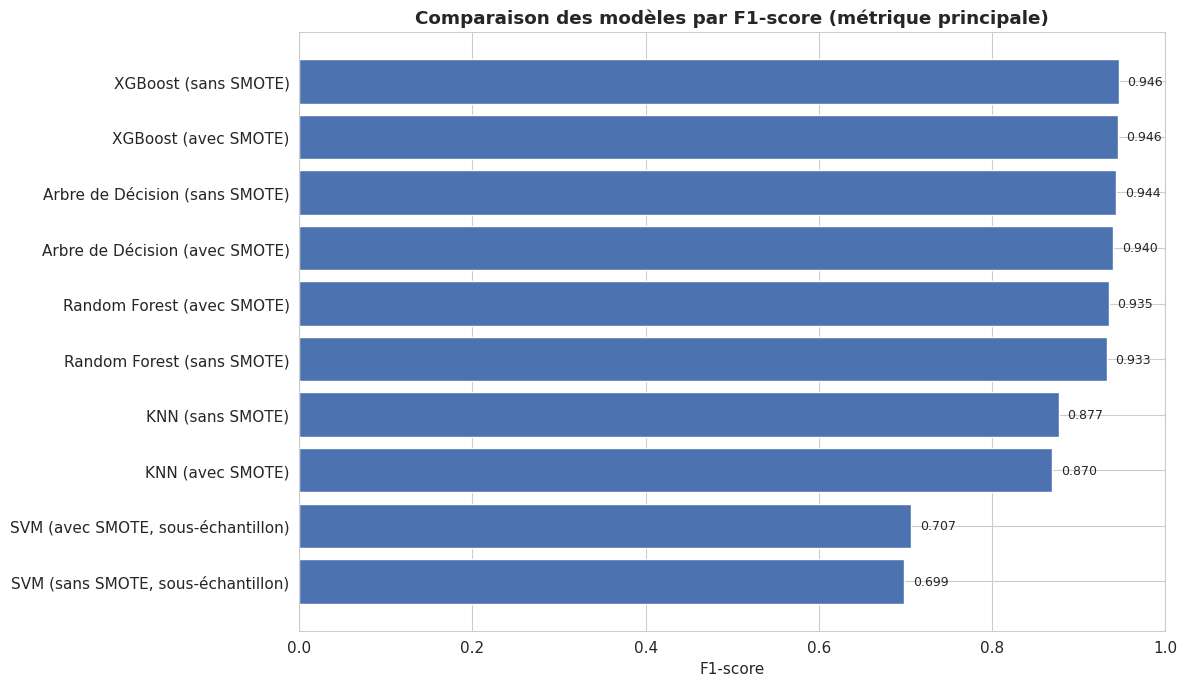

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))
comparaison_tri = comparaison.sort_values("F1-score", ascending=True)
ax.barh(comparaison_tri["Modèle"], comparaison_tri["F1-score"], color="#4C72B0")
ax.set_xlabel("F1-score")
ax.set_title("Comparaison des modèles par F1-score (métrique principale)", fontweight="bold")
ax.set_xlim(0, 1)
for i, v in enumerate(comparaison_tri["F1-score"]):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

### Quel modèle recommander, et pourquoi ?


**Recommandation** : sur ce jeu de données, XGBoost offre le meilleur F1-score et
ROC-AUC :  c'est le candidat à retenir par défaut

## 12. Importance des variables
Pour DT, Random Forest et XGBoost pour vérifier que les décisions du modèle sont **défendables d'un point de vue métier**, pas seulement statistiquement performantes sur ce jeu de test

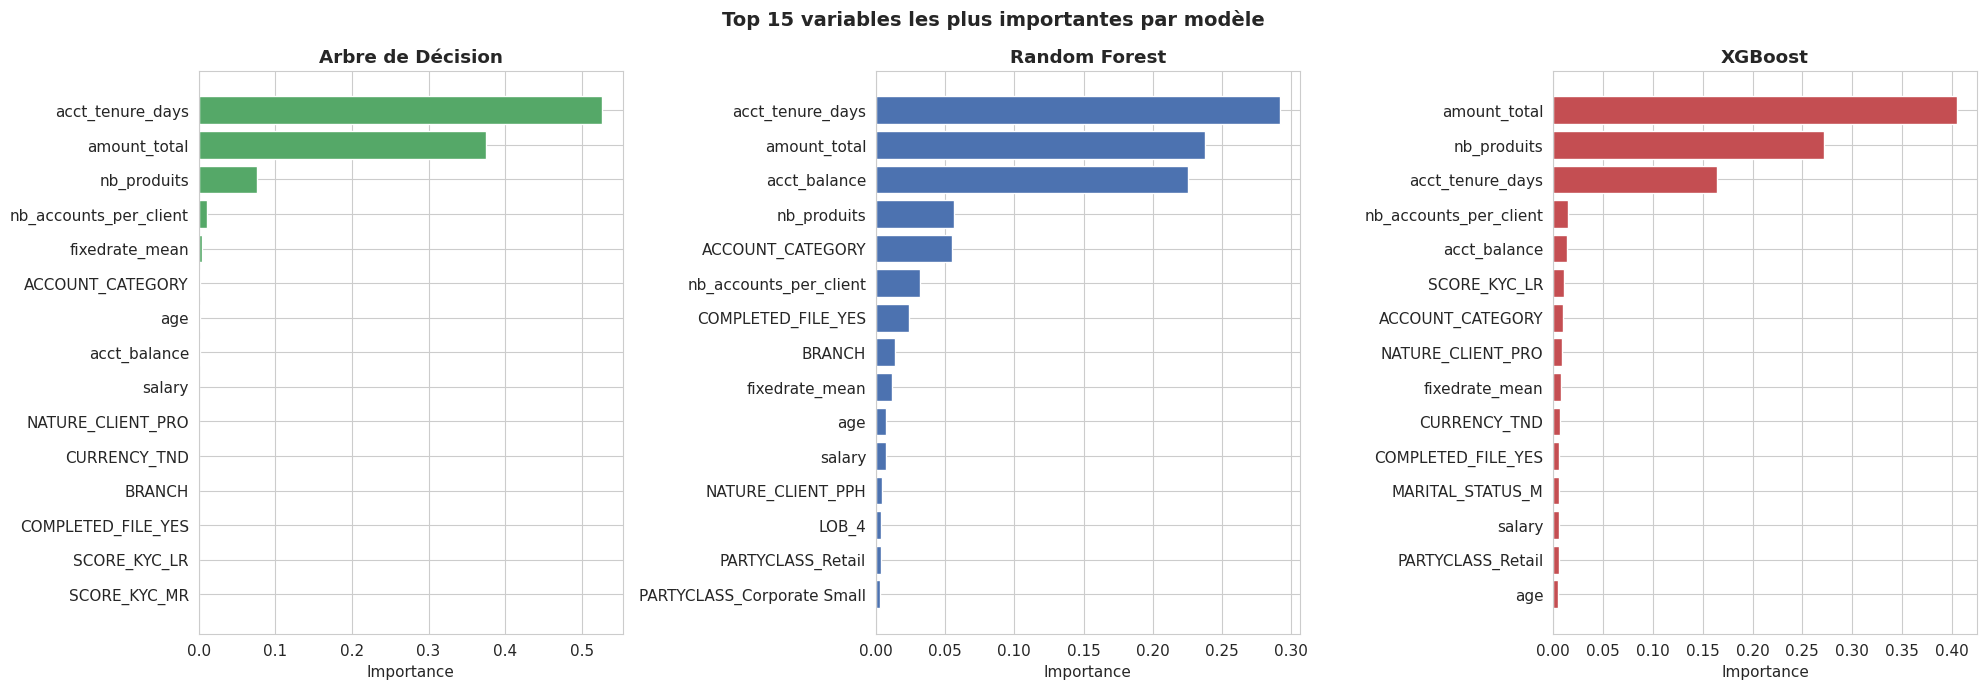

Variables les plus importantes (XGBoost, top 10) :
amount_total              0.404864
nb_produits               0.271678
acct_tenure_days          0.164212
nb_accounts_per_client    0.015308
acct_balance              0.013696
SCORE_KYC_LR              0.010554
ACCOUNT_CATEGORY          0.010330
NATURE_CLIENT_PRO         0.009129
fixedrate_mean            0.008264
CURRENCY_TND              0.006614
dtype: float32


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# --- Arbre de décision ---
importances_dt = pd.Series(dt.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
axes[0].barh(importances_dt.index[::-1], importances_dt.values[::-1], color="#55A868")
axes[0].set_title("Arbre de Décision", fontweight="bold")
axes[0].set_xlabel("Importance")

# --- Random Forest ---
importances_rf = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
axes[1].barh(importances_rf.index[::-1], importances_rf.values[::-1], color="#4C72B0")
axes[1].set_title("Random Forest", fontweight="bold")
axes[1].set_xlabel("Importance")

# --- XGBoost ---
importances_xgb = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
axes[2].barh(importances_xgb.index[::-1], importances_xgb.values[::-1], color="#C44E52")
axes[2].set_title("XGBoost", fontweight="bold")
axes[2].set_xlabel("Importance")

plt.suptitle("Top 15 variables les plus importantes par modèle", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Variables les plus importantes (XGBoost, top 10) :")
print(importances_xgb.head(10))

## 13. Conclusion

### 13.5 Modèle final recommandé

**XGBoost (sans SMOTE)** — meilleur F1-score et ROC-AUC du comparatif, tout en
restant rapide à entraîner. Sa fiabilité a été renforcée par la détection et la
correction d'une fuite d'information en section 4bis (voir 13.6 et la note
méthodologique de la section 12) avant l'entraînement final.

### 13.6 Pistes d'amélioration futures

- **Re-définition éventuelle du churn au niveau client** (plutôt que compte),
  explorée comme alternative documentée mais non retenue dans ce notebook — voir
  `01_etl/README.md` pour la discussion complète de ce choix de grain.